
# Regression Portfolio Project: Predicting CO2 Emissions
**Student Name:** Prayan Piya
**Student ID:** 2462985


## 1. Introduction
The objective of this project is to predict CO2 emissions (`co2`) using the `owid-co2-data.csv` dataset.
**Flow**: Data Cleaning -> Visualization -> Model Building -> Hyperparameter Optimization -> Feature Selection -> Final Model.

## 2. Methodology
1.  **Exploratory Data Analysis (EDA)**: Inspect, clean, summarize, and visualize data.
2.  **Task 2 - Neural Network**: `MLPRegressor` with continuous output.
3.  **Task 3 - Build Primary ML Models**: Linear Regression & Random Forest.
4.  **Task 4 - Hyperparameter Optimization**: GridSearchCV for Random Forest.
5.  **Task 5 - Feature Selection**: Recursive Feature Elimination (RFE).
6.  **Task 6 - Final Models & Comparative Analysis**: Rebuild and compare validation vs test performance.


In [53]:
# Import libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn preprocessing and model selection tools
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Import regression evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import Machine Learning models for Regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# Import Recursive Feature Elimination tool
from sklearn.feature_selection import RFE

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully



## 3. Exploratory Data Analysis (EDA)
Understanding the dataset characteristics before building models.


In [54]:
# 3.1 Data Loading & Initial Cleaning
df = pd.read_csv('owid-co2-data.csv')

# Remove columns where more than 50% of the data is missing to ensure feature quality
missing = df.isnull().mean()
df = df.drop(columns=missing[missing > 0.5].index)

# Fill remaining missing values: Mode for categorical, Median for numerical
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# Encode discrete categorical columns like 'country' and 'iso_code'
le = LabelEncoder()
if 'country' in df.columns:
    df['country'] = le.fit_transform(df['country'])
if 'iso_code' in df.columns:
    df['iso_code'] = le.fit_transform(df['iso_code'].astype(str))

print("Data Cleaned. Shape:", df.shape)

Data Cleaned. Shape: (25204, 23)


In [55]:

# 3.2 Summary Statistics
display(df.describe())
display(df.info())


,iso_code,country,year,co2,co2_growth_prct,co2_growth_abs,co2_per_capita,share_global_co2,cumulative_co2,share_global_cumulative_co2,...,coal_co2_per_capita,oil_co2_per_capita,share_global_coal_co2,share_global_oil_co2,cumulative_coal_co2,cumulative_oil_co2,share_global_cumulative_coal_co2,share_global_cumulative_oil_co2,population,gdp
count,25204.000000,25204.000000,25204.000000,25204.000000,25204.000000,25204.000000,25204.000000,25204.000000,2.520400e+04,25204.000000,...,25204.000000,25204.000000,25204.000000,25204.000000,25204.000000,25204.000000,25204.000000,25204.000000,2.520400e+04,2.520400e+04
mean,102.744207,121.345778,1953.225797,254.765957,20.906354,4.820064,3.950973,4.738796,9.845933e+03,4.872756,...,1.184038,2.235815,4.803326,2.454239,6026.817854,2693.669400,4.940411,2.459007,6.464678e+07,1.685963e+11
std,60.654586,71.872867,53.791369,1484.413417,698.752933,53.469956,14.360701,17.291753,5.970444e+04,18.048170,...,2.151696,13.561624,17.441595,10.908348,32567.560554,19580.519714,18.174341,11.012710,3.621476e+08,1.602900e+12
min,0.000000,0.000000,1750.000000,0.000000,-99.640000,-1895.244000,0.000000,0.000000,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.490000e+03,5.543200e+07
25%,61.000000,62.000000,1925.000000,0.594000,-0.360000,-0.004000,0.302000,0.010000,8.252750e+00,0.000000,...,0.160000,0.189000,0.030000,0.020000,23.263250,7.110750,0.020000,0.010000,1.631726e+06,2.630703e+10
50%,89.000000,118.000000,1967.000000,4.857000,3.350000,0.059000,1.250000,0.060000,9.131800e+01,0.030000,...,0.441500,0.630000,0.115000,0.080000,98.181500,39.164000,0.070000,0.070000,4.880320e+06,3.037019e+10
75%,155.000000,183.000000,1995.000000,38.329000,10.350000,0.907250,4.253250,0.530000,9.853170e+02,0.370000,...,1.008000,1.788250,0.370000,0.350000,382.599000,210.346250,0.270000,0.320000,1.477804e+07,3.634567e+10
max,218.000000,243.000000,2020.000000,36702.503000,102318.510000,1736.258000,748.639000,100.000000,1.696524e+06,100.000000,...,34.184000,748.639000,100.000000,100.000000,788362.044000,592621.162000,100.000000,100.000000,7.794799e+09,1.136300e+14


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25204 entries, 0 to 25203
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   iso_code                          25204 non-null  int64  
 1   country                           25204 non-null  int64  
 2   year                              25204 non-null  int64  
 3   co2                               25204 non-null  float64
 4   co2_growth_prct                   25204 non-null  float64
 5   co2_growth_abs                    25204 non-null  float64
 6   co2_per_capita                    25204 non-null  float64
 7   share_global_co2                  25204 non-null  float64
 8   cumulative_co2                    25204 non-null  float64
 9   share_global_cumulative_co2       25204 non-null  float64
 10  co2_per_gdp                       25204 non-null  float64
 11  coal_co2                          25204 non-null  float64
 12  oil_

None


### 3.3 Data Visualizations
Visualizing the dataset to understand distributions, relationships, and outliers.


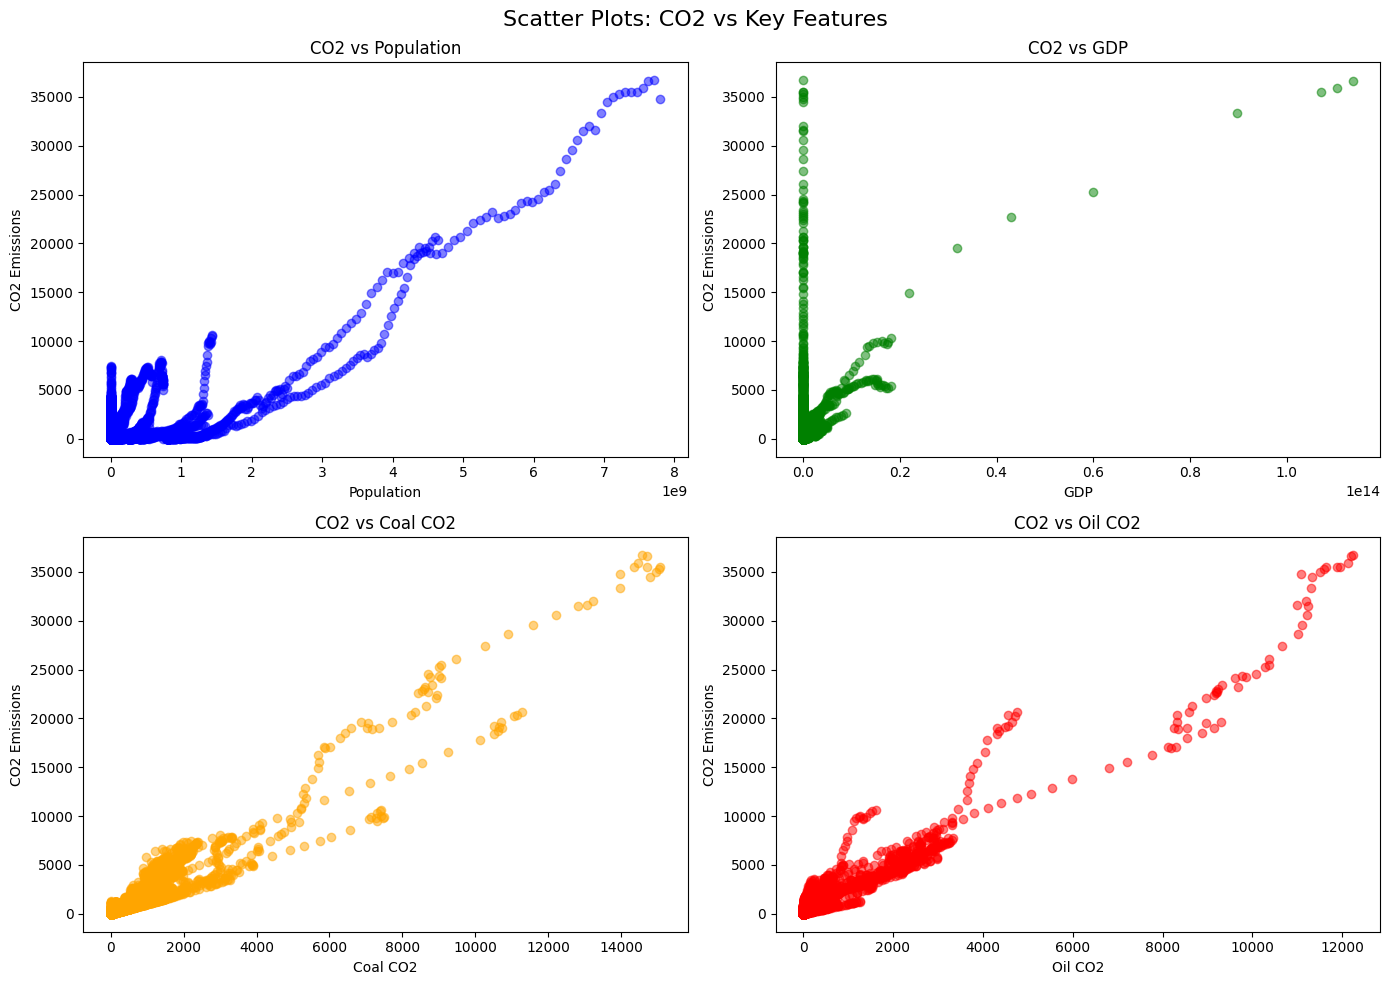

In [56]:
# Scatter Plots: Visualize relationships between CO2 and key predictors
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Scatter Plots: CO2 vs Key Features', fontsize=16)

# CO2 vs Population
axes[0, 0].scatter(df['population'], df['co2'], alpha=0.5, c='blue')
axes[0, 0].set_xlabel('Population')
axes[0, 0].set_ylabel('CO2 Emissions')
axes[0, 0].set_title('CO2 vs Population')

# CO2 vs GDP
axes[0, 1].scatter(df['gdp'], df['co2'], alpha=0.5, c='green')
axes[0, 1].set_xlabel('GDP')
axes[0, 1].set_ylabel('CO2 Emissions')
axes[0, 1].set_title('CO2 vs GDP')

# CO2 vs Coal CO2
axes[1, 0].scatter(df['coal_co2'], df['co2'], alpha=0.5, c='orange')
axes[1, 0].set_xlabel('Coal CO2')
axes[1, 0].set_ylabel('CO2 Emissions')
axes[1, 0].set_title('CO2 vs Coal CO2')

# CO2 vs Oil CO2
axes[1, 1].scatter(df['oil_co2'], df['co2'], alpha=0.5, c='red')
axes[1, 1].set_xlabel('Oil CO2')
axes[1, 1].set_ylabel('CO2 Emissions')
axes[1, 1].set_title('CO2 vs Oil CO2')

plt.tight_layout()
plt.show()


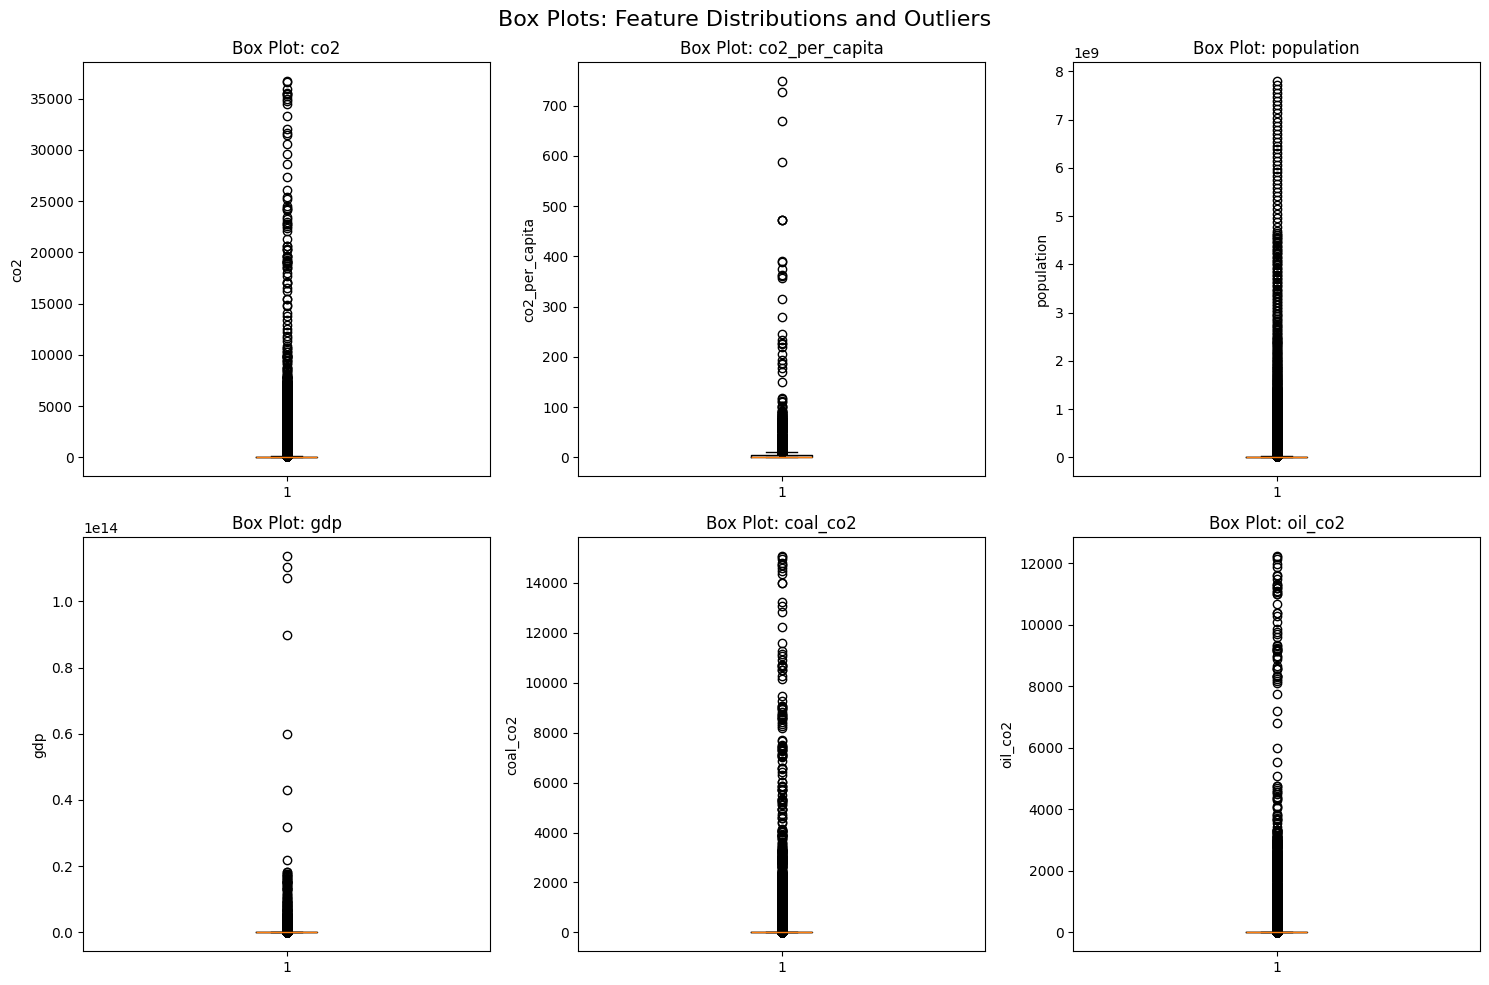

In [57]:
# Box Plots: Identify outliers and distribution patterns
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Box Plots: Feature Distributions and Outliers', fontsize=16)

# Define features to plot
features_to_plot = ['co2', 'co2_per_capita', 'population', 'gdp', 'coal_co2', 'oil_co2']

for idx, feature in enumerate(features_to_plot):
    row = idx // 3
    col = idx % 3
    axes[row, col].boxplot(df[feature].dropna())
    axes[row, col].set_title(f'Box Plot: {feature}')
    axes[row, col].set_ylabel(feature)

plt.tight_layout()
plt.show()


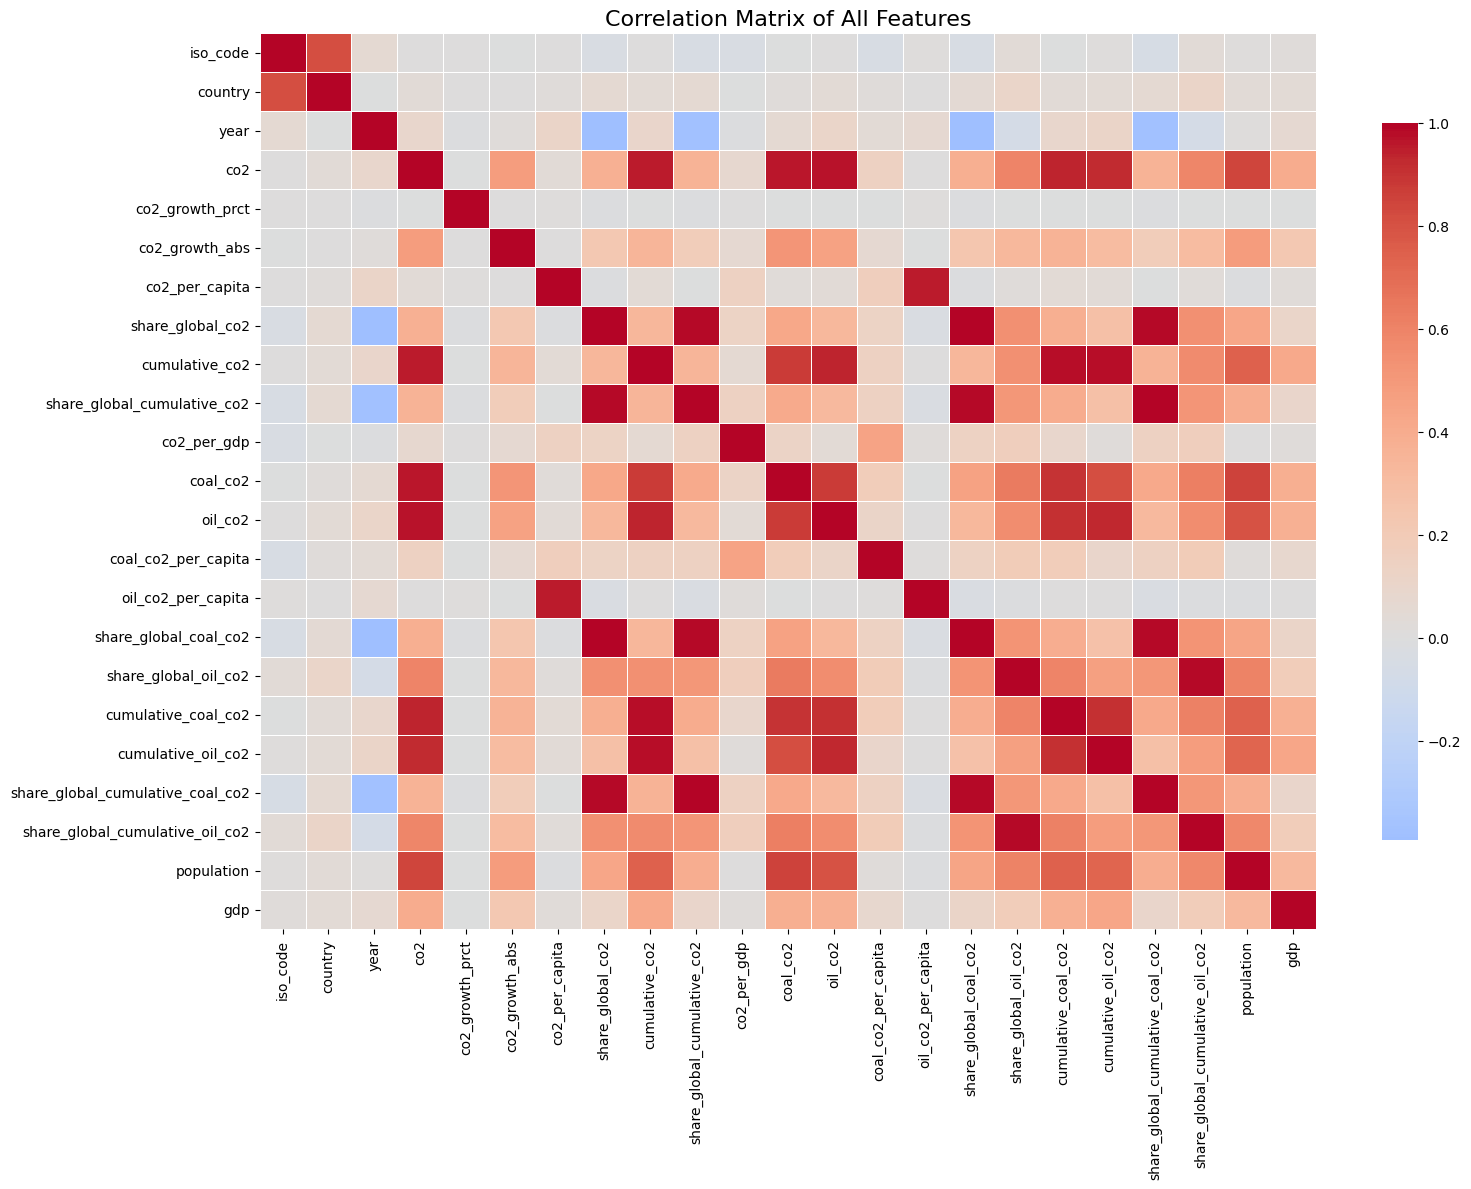


Top 10 features most correlated with CO2:
co2                                1.000000
oil_co2                            0.971033
coal_co2                           0.962852
cumulative_co2                     0.951706
cumulative_coal_co2                0.937380
cumulative_oil_co2                 0.924856
population                         0.845369
share_global_oil_co2               0.593646
share_global_cumulative_oil_co2    0.586974
co2_growth_abs                     0.481117
gdp                                0.401756
Name: co2, dtype: float64


In [58]:
# Correlation Matrix: Heatmap showing relationships between all features
plt.figure(figsize=(16, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of All Features', fontsize=16)
plt.tight_layout()
plt.show()

# Display features most correlated with CO2
print("\nTop 10 features most correlated with CO2:")
co2_correlations = correlation_matrix['co2'].abs().sort_values(ascending=False)
print(co2_correlations.head(11))  # Top 11 (including CO2 itself)


In [59]:
# Prepare feature matrix X and target vector y
X = df.drop(['co2'], axis=1)
y = df['co2']

# Standardize the features for models like Neural Networks
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled and ready for modeling.")

Features scaled and ready for modeling.



### Interpretation
- **Distribution**: The histogram shows the distribution of CO2 emissions. It is likely right-skewed.
- **Correlation**: The heatmap helps identify collinearity and features strongly correlated with the target.
- **Scatter Plot**: Visualizes the relationship between CO2 and its strongest predictor.


In [60]:
# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define architecture for MLPRegressor (Neural Network)
nn_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)

# Train the Neural Network model
nn_model.fit(X_train, y_train)

# Evaluate metrics on the test set
y_pred_nn = nn_model.predict(X_test)
print(f"Neural Network R2 Score: {r2_score(y_test, y_pred_nn):.4f}")

Neural Network R2 Score: 0.9992



## 4. Task 2: Build a Neural Network Model
**Architecture**:
- **Type**: MLPRegressor (Multi-layer Perceptron).
- **Hidden Layers**: (100, 50) - Two hidden layers with 100 and 50 neurons respectively.
- **Activation**: ReLU (Rectified Linear Unit).
- **Optimizer**: Adam.
- **Loss Function**: Squared Error.


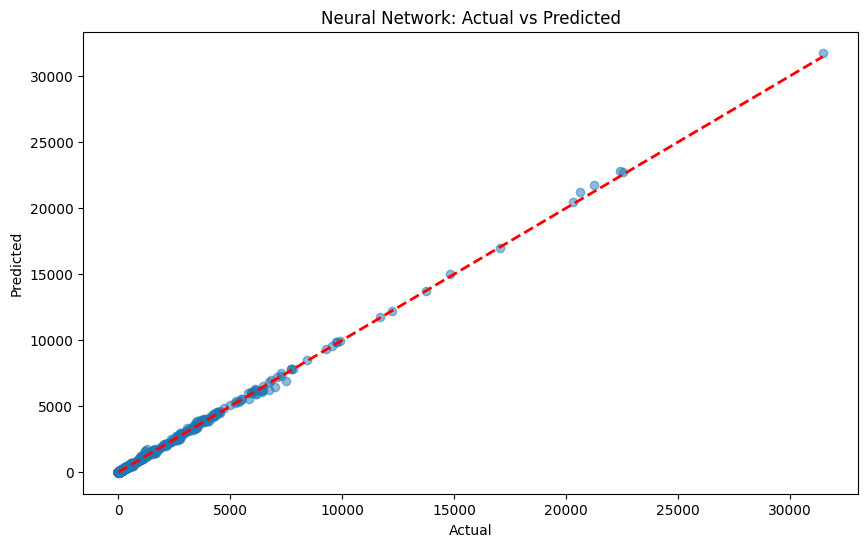

In [61]:
y_pred_nn = nn_model.predict(X_test)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_nn, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Neural Network: Actual vs Predicted')
plt.show()

In [62]:

# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 2. Random Forest Regressor
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluation Function
def print_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R-squared: {r2:.4f}")
    return r2

r2_lr_initial = print_metrics(y_test, y_pred_lr, "Linear Regression (Initial)")
r2_rf_initial = print_metrics(y_test, y_pred_rf, "Random Forest (Initial)")


--- Linear Regression (Initial) ---
MSE: 1396.30
RMSE: 37.37
MAE: 10.84
R-squared: 0.9990
--- Random Forest (Initial) ---
MSE: 2002.24
RMSE: 44.75
MAE: 6.13
R-squared: 0.9986



### Initial Comparison
The Random Forest model typically performs better on complex datasets due to its ability to capture non-linear relationships, whereas Linear Regression assumes a linear relationship.


# Perform Recursive Feature Elimination to narrow down the top 10 predictors
rfe = RFE(estimator=LinearRegression(), n_features_to_select=10)
rfe.fit(X_train, y_train)

# Display the names of selected features
selected_features = X.columns[rfe.support_]
print("Selected Features:", selected_features.tolist())

In [63]:

param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, verbose=1, n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf_params = grid_rf.best_params_
best_rf_score = grid_rf.best_score_

print(f"Best Random Forest Params: {best_rf_params}")
print(f"Best CV Score (R2): {best_rf_score:.4f}")


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Random Forest Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score (R2): 0.9976


# Filter data to only include the selected features from RFE
X_train_rfe = pd.DataFrame(X_train, columns=X.columns)[selected_features]
X_test_rfe = pd.DataFrame(X_test, columns=X.columns)[selected_features]

# Re-train Random Forest with best parameters on top features
final_model = RandomForestRegressor(**grid_rf.best_params_, random_state=42)
final_model.fit(X_train_rfe, y_train)

# Calculate final error and fit metrics
y_pred_final = final_model.predict(X_test_rfe)
print(f"Final Model MAE: {mean_absolute_error(y_test, y_pred_final):.4f}")
print(f"Final Model MSE: {mean_squared_error(y_test, y_pred_final):.4f}")
print(f"Final Model R2: {r2_score(y_test, y_pred_final):.4f}")

In [66]:

# Apply RFE to Linear Regression
rfe_lr = RFE(estimator=lr, n_features_to_select=10) # Selecting top 10 features
rfe_lr.fit(X_train, y_train)
X_train_lr_sel = rfe_lr.transform(X_train)
X_test_lr_sel = rfe_lr.transform(X_test)

# Apply RFE to Random Forest (using best params or base model)
# We use the best estimator from optimization for feature selection source if possible, or a base RF
best_rf_model = grid_rf.best_estimator_
rfe_rf = RFE(estimator=best_rf_model, n_features_to_select=10)
rfe_rf.fit(X_train, y_train)
X_train_rf_sel = rfe_rf.transform(X_train)
X_test_rf_sel = rfe_rf.transform(X_test)

print(f"Selected {rfe_lr.n_features_} features for LR.")
print(f"Selected {rfe_rf.n_features_} features for RF.")


Selected 10 features for LR.
Selected 10 features for RF.



## 8. Task 6: Final Models and Comparative Analysis
Rebuilding models with optimal hyperparameters and selected features.


,Model,Features Used,CV Score,Test RMSE,Test R-squared
0,Linear Regression,Selected (10),0.999405,38.252802,0.998998
1,Random Forest,Selected (10),0.999134,41.421643,0.998825


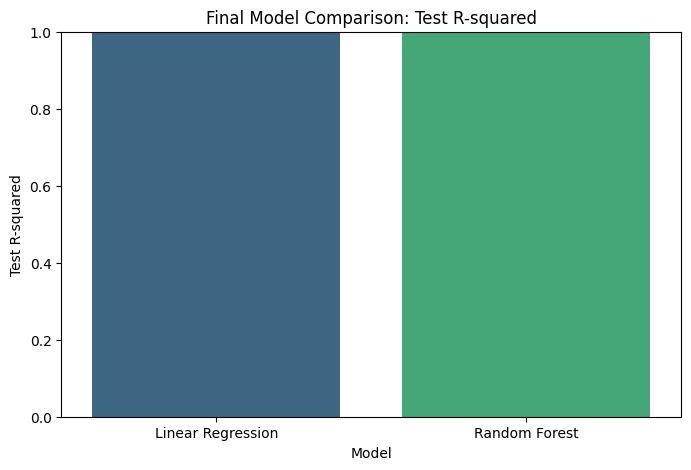

In [67]:

# 1. Final Linear Regression (Selected Features)
final_lr = LinearRegression()
final_lr.fit(X_train_lr_sel, y_train)
y_pred_final_lr = final_lr.predict(X_test_lr_sel)

# CV Score for Final LR (on training set with selected features)
cv_lr = cross_val_score(final_lr, X_train_lr_sel, y_train, cv=5, scoring='r2').mean()
rmse_final_lr = np.sqrt(mean_squared_error(y_test, y_pred_final_lr))
r2_final_lr = r2_score(y_test, y_pred_final_lr)


# 2. Final Random Forest (Selected Features + Optimized Params)
final_rf = RandomForestRegressor(**best_rf_params, random_state=42, n_jobs=-1)
final_rf.fit(X_train_rf_sel, y_train)
y_pred_final_rf = final_rf.predict(X_test_rf_sel)

# CV Score for Final RF
cv_rf = cross_val_score(final_rf, X_train_rf_sel, y_train, cv=5, scoring='r2').mean()
rmse_final_rf = np.sqrt(mean_squared_error(y_test, y_pred_final_rf))
r2_final_rf = r2_score(y_test, y_pred_final_rf)

# Comparison Table
comparison_data = {
    'Model': ['Linear Regression', 'Random Forest'],
    'Features Used': ['Selected (10)', 'Selected (10)'],
    'CV Score': [cv_lr, cv_rf],
    'Test RMSE': [rmse_final_lr, rmse_final_rf],
    'Test R-squared': [r2_final_lr, r2_final_rf]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# Visualizing Final Performance
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Test R-squared', data=comparison_df, palette='viridis')
plt.ylim(0, 1)
plt.title('Final Model Comparison: Test R-squared')
plt.show()
